<a href="https://colab.research.google.com/github/Elpog1/EMSC2010-W9-P1/blob/main/EMSC2010_W9_P1_NB1_u8222275ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010-W9-P1-NB1

### Soil temperature model

We will simulate heat diffusing down through a column of soil after the surface is set to a fixed temperature.

Key aspects of the model:

1. The soil column — a list of temperatures, one per layer, all starting at the same value (the so-called *initial* conditions)

2. *Boundary* conditions — the surface layer is fixed at one temperature throughout, and the bottom layer is fixed at another. These layers will not change their temperature during the simulation.

3. The update rule — at each model time step, every interior soil layer (i.e., not the surface or bottom-most layer) adjusts its temperature based on its neighbours:

$T_i^{\mathrm{new}} = T_i + \kappa \frac{\Delta t}{(\Delta z)^2} (T_{i+1}-2*T_i+T_{i-1})$

* $T$ is a list of temperatures, one per layer for $n$ layers ($i$ denotes which layer we are referring to with $i = 0$ being the top layer)
* $\kappa$ thermal diffusivity of soil (m$^2$/s), 1e-6 m$^2$/s is typical for dry soil.
* $\Delta z$ is the thickness of the layers (m).
* $\Delta t$ is the time step (s).

In words this equations says: if your neighbours are on average warmer than you, warm up a little; if they are cooler, cool down a little. The term in brackets is just the average of the neighbours minus your own temperature.

Now we can set up the model. First we'll import the required packages.

In [57]:
import numpy as np
import matplotlib.pyplot as plt

We can define the size and properties of the soil column.

In [58]:
num_layers = 20 # number of soil layers
dz = 0.1 # thickness of each layer (metres)
depth = num_layers * dz # total depth of column (metres)
kappa = 1e-6 # thermal diffusivity of the soil (m^2/s)

Next, we'll set up the initial temperture conditions and the boundary conditions.

In [59]:
T_initial = 0.0 # starting temperature throughout the interior of the soil column (°C)
T_surface  = 20.0 # fixed surface temperature (°C)
T_bottom   = 10.0 # fixed bottom temperature (°C)

# Create an array of temperatures, one per layer, all starting at T_initial
T = np.ones(num_layers) * T_initial

# Fix the boundary conditions (surface and bottom never change temperature)
T[0]  = T_surface # set the surface layer
T[-1] = T_bottom # set the bottom layer

We also need to define how time will evolve through the model. Specifically, the time step with which we'll update the temperature and the number of time steps we'll run the model for. Time = 0 will represent the initial model conditions.

In [60]:
dt = 3800.0 # time step (seconds) -- one hour
num_steps = 500 # how many time steps to run

We'll also set up an output variable, where we can record the model temperatures through time for plotting after the model has finished running.

In [61]:
T_output = [] #create an empty list
T_output.append(T.copy()) #record the initial temperatures with a copy of T

In [62]:
for step in range(1, num_steps + 1): #loop through the time steps

    T_new = T.copy() # start with current temperatures

    # Update every interior layer (not the surface or bottom -- those are fixed)
    for i in range(1, num_layers - 1):

        # The update rule:
        # If neighbours are warmer on average, this layer warms up a little.
        # If neighbours are cooler on average, this layer cools down a little.
        T_new[i] = T[i] + kappa * (dt / dz**2) * (T[i+1] - 2*T[i] + T[i-1])

    T = T_new #set the temperature to T_new before looping around again
    T_output.append(T.copy()) #record the current temperatures with a copy of T

We can now plot the model results. As you plot the time steps you'll see how the temperature evolves towards equilibrium. Specfically:

* Early time steps: only the top layers have warmed, the deep layers are unchanged.

* Middle time steps: the warming front has propagated part of the way down the profile.

* Final equilibrium: a straight line from surface to bottom temperature.

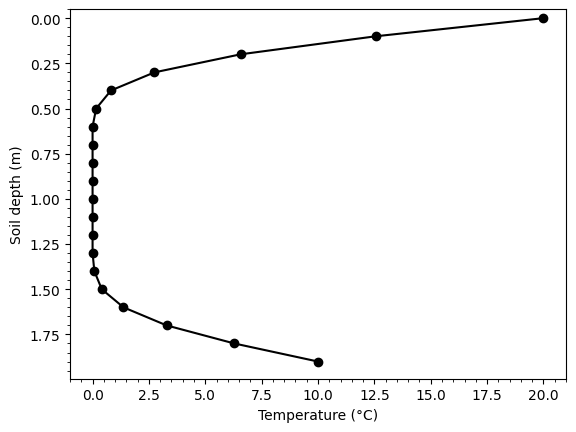

In [63]:
plot_step = 5 #choose which time step to plot
plot_depth = np.arange(0, depth, dz) #depth of each layer
plt.plot(T_output[plot_step],plot_depth,'ok-') #plot layer temperature versus depth
plt.xlabel('Temperature (°C)') #label the x-axis
plt.ylabel('Soil depth (m)') #label the y-axis
plt.ylim(bottom=-0.05) #limit the y-axis
plt.gca().invert_yaxis() #switch the direction of the y-axis
plt.minorticks_on() #add minor ticks

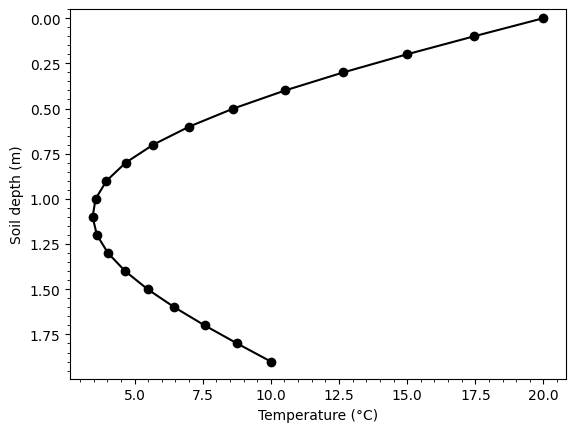

In [64]:
plot_step = 50 #choose which time step to plot
plot_depth = np.arange(0, depth, dz) #depth of each layer
plt.plot(T_output[plot_step],plot_depth,'ok-') #plot layer temperature versus depth
plt.xlabel('Temperature (°C)') #label the x-axis
plt.ylabel('Soil depth (m)') #label the y-axis
plt.ylim(bottom=-0.05) #limit the y-axis
plt.gca().invert_yaxis() #switch the direction of the y-axis
plt.minorticks_on() #add minor ticks

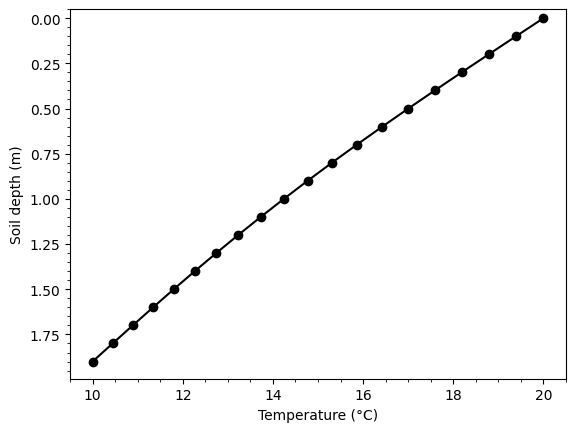

In [65]:
plot_step = 350 #choose which time step to plot
plot_depth = np.arange(0, depth, dz) #depth of each layer
plt.plot(T_output[plot_step],plot_depth,'ok-') #plot layer temperature versus depth
plt.xlabel('Temperature (°C)') #label the x-axis
plt.ylabel('Soil depth (m)') #label the y-axis
plt.ylim(bottom=-0.05) #limit the y-axis
plt.gca().invert_yaxis() #switch the direction of the y-axis
plt.minorticks_on() #add minor ticks

We can also plot how the temperaure of a given layer changes through time.

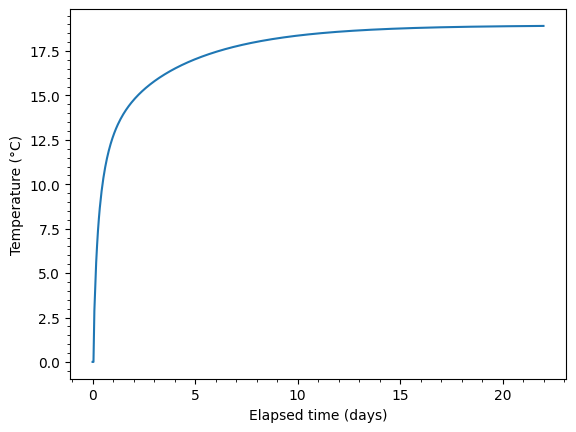

In [66]:
depth_index = 2   # index of the layer you want to plot
time_series = [T[depth_index] for T in T_output] #bit of Python magic to extract the values
time_plot = np.arange(0, num_steps * dt + 1, dt)/(60*60*24) #time in days
plt.plot(time_plot,time_series) #plot the temperature over time for the given layer
plt.xlabel('Elapsed time (days)') #label the y-axis
plt.ylabel('Temperature (°C)') #label the x-axis
plt.minorticks_on()

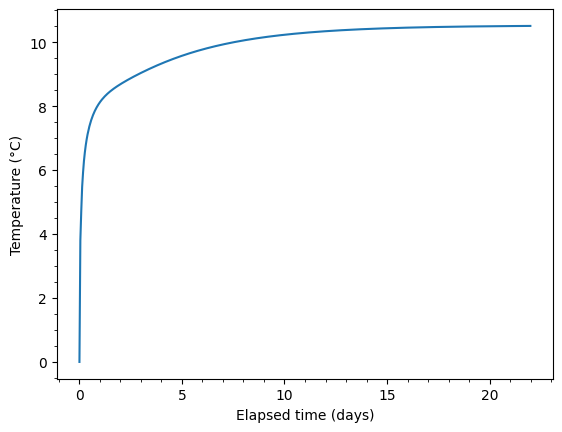

In [67]:
depth_index = 18   # index of the layer you want to plot
time_series = [T[depth_index] for T in T_output] #bit of Python magic to extract the values
time_plot = np.arange(0, num_steps * dt + 1, dt)/(60*60*24) #time in days
plt.plot(time_plot,time_series) #plot the temperature over time for the given layer
plt.xlabel('Elapsed time (days)') #label the y-axis
plt.ylabel('Temperature (°C)') #label the x-axis
plt.minorticks_on()

Now that we've set up the model, run the following experiments:

1. How does thermal diffusivity control how long it takes to reach thermal equilibrium? Compare the following:
* Dry soil: $\kappa$ = 1 $\times$ 10$^{-6}$ m$^2$/s
* Rock-bearing soil: $\kappa$ = 1.5 $\times$ 10$^{-6}$ m$^2$/s
* Wet clay soil: $\kappa$ = 4 $\times$ 10$^{-7}$ m$^2$/s

2. If the bottom boundary condition temperature is higher than the surface, how does the evolution of the temperature profile change?

### Ensuring numerical stability (very important)

At each time step, a layer exchanges heat with its neighbours. The update rule says:

new temperature = current temperature + a correction based on the difference with neighbours.

The correction term has a size controlled by the ratio: $\kappa \frac{\Delta t}{(\Delta z)^2}$.

If this ratio is small, each layer adjusts its temperature by a small amount, which will produce a numerically *stable* solution.

If this ratio is large, each layer overcorrects. It overshoots past its neighbours' temperatures, which then overcorrect back in the next step, and the whole thing spirals into a meaningless solution.

Therefore there must be a balance between the thickness of the soil layers and the time step. To see the effect of a time step that is too large given the layer thickness, increase ```dt``` by a factor of 2 in the code above.

#### Model stability condition

For this model, we can obtain a stable model if:

$\Delta t \leq \frac{\Delta z^2}{2 k}$

This shows how modelling can be so computationally expensive because to get a meaningful result you may need to use a short time scale (a real problem if you are interested in change on geological time scales).

For example, using thin soil layers in the model will provide us with a smoother and more realistic temperature profile. However, if we halve the layer thickness ($\Delta z$) then we must reduce $\Delta t$ by a factor of 4 to stay stable. So as we try to resolve detail in terms of depth the computational cost will grow rapidly.

There is a trade-off between accuracy (wanting thin layers and small time steps) and computational cost (wanting as few steps as possible). This trade-off is fundamental to numerical modelling. Additionally, as models become more complex, it can become (very) challenging to determine the model stability conditions.